# Capstone Project Starter Notebook

## Applied Python for Data Analysis

This notebook is a scaffold for your capstone project. It is designed to help you organize your work, document your thinking, and complete a clear data analysis workflow.

You should replace the placeholder text, complete the TODOs, and add your own analysis throughout.

---

## Capstone Goal

Your project should answer **one clear analytical question** using Python and data.

You will:
- Load and inspect your dataset
- Clean and prepare the data
- Explore the data with summary statistics and visualizations
- Generate insights and recommendations
- Optionally build a simple predictive model


## 1. Problem Statement

Write your problem statement below.

Use the SMART framework:

- **Specific:** What exactly are you trying to answer?
- **Measurable:** What data will you use?
- **Achievable:** Can this be answered with your dataset?
- **Relevant:** Why does this matter?
- **Time-bound:** Is there a time component?

### Problem Statement

> TODO: Write your problem statement here.
> What are the usual patterns for returned items? What factors can help us predict whether an order will be returned or not?
> I want to explore this dat aand see what datapoints directly affect the return rate for orders whther its category, customer, segment or another factor.

### Audience

> TODO: Who is this analysis for?
>This analysis would before c-suite for operations and whoever would be in charge of returns.
### Primary Business / Analytical Question

> TODO: What main question will your project answer?
> What factors are commonly associated with returns, find relationships between different variables and are there factors causing them we can prevent.
> The factors that include increase r ates of ereturn products may be increased operations cost , decrease in customer satisfcation , which can affect
> market share and so on its also important because return show how effivcient a company's operations are
> A poor experince will always stick to someones' mind rather than agood one . If we can identify how we can reduce returns we can reduce costs associated with them and  improve customer satisfaction

## 2. Imports and Setup

Run this cell first.

You may add additional libraries if needed.


In [4]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# File path tools
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 3. File Paths

Update the file path below so it points to your raw dataset.

Recommended project structure:

```text
data/
├── raw/
│   └── your_dataset.csv
└── processed/
    └── cleaned_dataset.csv
```


In [6]:
RAW_DATA = Path('..') / 'data' / 'capstone_dataset.csv'

cap_data_raw = pd.read_csv(RAW_DATA)

## 4. Load the Dataset

Load your dataset into a pandas DataFrame.

If your file is not a CSV, adjust the code accordingly.


In [8]:

cap_data_raw.head()

,transaction_id,date,customer_id,customer_segment,product_category,product_price,quantity,discount_applied,marketing_channel,region,total_revenue,customer_satisfaction,returned
0,TXN-00180,2025-01-01,CUST-3509,New,Beauty,324.06,1,0.10,Email,Central,295.34,4.0,0
1,TXN-00303,2025-01-02,CUST-2891,Returning,Beauty,352.42,5,0.00,Direct,North,1758.36,4.0,0
2,TXN-00421,2025-01-02,CUST-4935,Returning,Books,457.24,2,0.00,Organic Search,Central,925.65,4.0,0
3,TXN-00163,2025-01-02,CUST-2020,Returning,Electronics,52.72,1,0.10,Direct,Central,43.75,4.0,0
4,TXN-00032,2025-01-04,CUST-3205,New,Books,299.91,3,0.15,Direct,East,783.52,5.0,0


## 5. Initial Data Inspection

Use this section to understand the basic structure of your dataset.

Questions to answer:
- How many rows and columns are there?
- What does each row represent?
- What are the column names?
- What data types are present?
- Are there missing values?


1. There are 500 Columns and 13 Rows
2. Each row represents an order 
3. The column names are: transaction_id', 'date', 'customer_id', 'customer_segment',
       'product_category', 'product_price', 'quantity', 'discount_applied',
       'marketing_channel', 'region', 'total_revenue', 'customer_satisfaction',
       'returned'
4.There are object , floats and  integers
5. There are missing valeues for discoubnt applied and customer satisfaction

In [11]:
# Shape of the dataset

cap_data_raw.shape

(500, 13)

In [12]:
# Column names

cap_data_raw.columns

Index(['transaction_id', 'date', 'customer_id', 'customer_segment',
       'product_category', 'product_price', 'quantity', 'discount_applied',
       'marketing_channel', 'region', 'total_revenue', 'customer_satisfaction',
       'returned'],
      dtype='object')

In [13]:
# Data types and missing values

cap_data_raw.dtypes

transaction_id            object
date                      object
customer_id               object
customer_segment          object
product_category          object
product_price            float64
quantity                   int64
discount_applied         float64
marketing_channel         object
region                    object
total_revenue            float64
customer_satisfaction    float64
returned                   int64
dtype: object

In [14]:
#get teh column info 
cap_data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         500 non-null    object 
 1   date                   500 non-null    object 
 2   customer_id            500 non-null    object 
 3   customer_segment       500 non-null    object 
 4   product_category       500 non-null    object 
 5   product_price          500 non-null    float64
 6   quantity               500 non-null    int64  
 7   discount_applied       495 non-null    float64
 8   marketing_channel      500 non-null    object 
 9   region                 500 non-null    object 
 10  total_revenue          500 non-null    float64
 11  customer_satisfaction  490 non-null    float64
 12  returned               500 non-null    int64  
dtypes: float64(4), int64(2), object(7)
memory usage: 50.9+ KB


In [15]:
# Summary statistics for numeric columns

cap_data_raw.describe()


,product_price,quantity,discount_applied,total_revenue,customer_satisfaction,returned
count,500.000000,500.000000,495.000000,500.000000,490.000000,500.000000
mean,266.594660,3.032000,0.075051,769.146000,3.865306,0.072000
std,142.045942,1.423738,0.070773,594.522332,0.638105,0.258747
min,15.120000,1.000000,0.000000,10.000000,2.000000,0.000000
25%,146.555000,2.000000,0.000000,282.042500,3.000000,0.000000
50%,272.035000,3.000000,0.050000,644.250000,4.000000,0.000000
75%,389.152500,4.000000,0.125000,1181.647500,4.000000,0.000000
max,499.690000,5.000000,0.250000,2469.200000,5.000000,1.000000


In [16]:
# Summary statistics for non-numeric columns

cap_data_raw.describe(include='object')

,transaction_id,date,customer_id,customer_segment,product_category,marketing_channel,region
count,500,500,500,500,500,500,500
unique,500,268,472,3,6,6,5
top,TXN-00180,2025-08-05,CUST-2552,Returning,Beauty,Direct,West
freq,1,8,4,210,94,95,108


In [17]:
# Missing values by column

cap_data_raw.isnull().sum()

transaction_id            0
date                      0
customer_id               0
customer_segment          0
product_category          0
product_price             0
quantity                  0
discount_applied          5
marketing_channel         0
region                    0
total_revenue             0
customer_satisfaction    10
returned                  0
dtype: int64

In [18]:
cap_data_raw.isna().sum()

transaction_id            0
date                      0
customer_id               0
customer_segment          0
product_category          0
product_price             0
quantity                  0
discount_applied          5
marketing_channel         0
region                    0
total_revenue             0
customer_satisfaction    10
returned                  0
dtype: int64

In [19]:
# Duplicate rows

cap_data_raw.duplicated().sum()

0

## 6. Data Cleaning

Use this section to clean your dataset.

Common cleaning tasks:
- Fix column names
- Convert data types
- Handle missing values
- Remove duplicates
- Fix inconsistent categories
- Create helpful new columns

Document every major cleaning decision in markdown.


In [21]:
# Make a copy before cleaning

cap_clean = cap_data_raw.copy()

In [22]:
cap_clean.head()

,transaction_id,date,customer_id,customer_segment,product_category,product_price,quantity,discount_applied,marketing_channel,region,total_revenue,customer_satisfaction,returned
0,TXN-00180,2025-01-01,CUST-3509,New,Beauty,324.06,1,0.10,Email,Central,295.34,4.0,0
1,TXN-00303,2025-01-02,CUST-2891,Returning,Beauty,352.42,5,0.00,Direct,North,1758.36,4.0,0
2,TXN-00421,2025-01-02,CUST-4935,Returning,Books,457.24,2,0.00,Organic Search,Central,925.65,4.0,0
3,TXN-00163,2025-01-02,CUST-2020,Returning,Electronics,52.72,1,0.10,Direct,Central,43.75,4.0,0
4,TXN-00032,2025-01-04,CUST-3205,New,Books,299.91,3,0.15,Direct,East,783.52,5.0,0


In [23]:
cap_clean.columns

Index(['transaction_id', 'date', 'customer_id', 'customer_segment',
       'product_category', 'product_price', 'quantity', 'discount_applied',
       'marketing_channel', 'region', 'total_revenue', 'customer_satisfaction',
       'returned'],
      dtype='object')

In [24]:
# Optional: standardize column names
#cap_clean = cap_clean.rename(columns={

   # 'customer_segment':'segment',
   # 'product_category':'category',
   # 'product_price':'price',
   # 'discount_applied':'discount',
   # 'marketing_channel':'channel',
    #'total_revenue':'revenue'
#})

In [25]:
# TODO: Convert date columns if your dataset has them
# Example:
cap_clean["date"] = pd.to_datetime(cap_clean["date"])




In [26]:
cap_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   transaction_id         500 non-null    object        
 1   date                   500 non-null    datetime64[ns]
 2   customer_id            500 non-null    object        
 3   customer_segment       500 non-null    object        
 4   product_category       500 non-null    object        
 5   product_price          500 non-null    float64       
 6   quantity               500 non-null    int64         
 7   discount_applied       495 non-null    float64       
 8   marketing_channel      500 non-null    object        
 9   region                 500 non-null    object        
 10  total_revenue          500 non-null    float64       
 11  customer_satisfaction  490 non-null    float64       
 12  returned               500 non-null    int64         
dtypes: da

In [27]:
# TODO: Handle missing values
# Example strategies:
cap_clean["discount_applied"] = cap_clean["discount_applied"].fillna(cap_clean["discount_applied"].median())
cap_clean["customer_satisfaction"] = cap_clean["customer_satisfaction"].fillna(cap_clean["customer_satisfaction"].median())
# df_clean["category_column"] = df_clean["category_column"].fillna("Unknown")




In [28]:
# TODO: Remove duplicate rows if appropriate
# df_clean = df_clean.drop_duplicates()


print(cap_clean.isnull().sum())

transaction_id           0
date                     0
customer_id              0
customer_segment         0
product_category         0
product_price            0
quantity                 0
discount_applied         0
marketing_channel        0
region                   0
total_revenue            0
customer_satisfaction    0
returned                 0
dtype: int64


In [29]:
# TODO: Check categorical columns for inconsistent labels
# Example:
cap_clean["customer_segment"].value_counts()

# Replace "category_column" with an actual column name


customer_segment
Returning    210
New          207
VIP           83
Name: count, dtype: int64

In [30]:
cap_clean["product_category"].value_counts()

product_category
Beauty           94
Electronics      88
Books            87
Home & Garden    82
Clothing         81
Sports           68
Name: count, dtype: int64

In [31]:
cap_clean["region"].value_counts()

region
West       108
Central    104
North       99
South       96
East        93
Name: count, dtype: int64

In [32]:
# Optional: create new useful columns
# Example for e-commerce dataset:
cap_clean["estimated_revenue"] = ((
     cap_clean["product_price"] 
     * cap_clean["quantity"] )
     * (1 - cap_clean["discount_applied"]))





In [33]:
cap_clean.head()

,transaction_id,date,customer_id,customer_segment,product_category,product_price,quantity,discount_applied,marketing_channel,region,total_revenue,customer_satisfaction,returned,estimated_revenue
0,TXN-00180,2025-01-01,CUST-3509,New,Beauty,324.06,1,0.10,Email,Central,295.34,4.0,0,291.6540
1,TXN-00303,2025-01-02,CUST-2891,Returning,Beauty,352.42,5,0.00,Direct,North,1758.36,4.0,0,1762.1000
2,TXN-00421,2025-01-02,CUST-4935,Returning,Books,457.24,2,0.00,Organic Search,Central,925.65,4.0,0,914.4800
3,TXN-00163,2025-01-02,CUST-2020,Returning,Electronics,52.72,1,0.10,Direct,Central,43.75,4.0,0,47.4480
4,TXN-00032,2025-01-04,CUST-3205,New,Books,299.91,3,0.15,Direct,East,783.52,5.0,0,764.7705


In [34]:
# Getting the name of teh month and number for each order/return 
cap_clean['month_name'] = cap_clean['date'].dt.strftime('%B')
cap_clean['month_num'] = cap_clean['date'].dt.month

In [35]:

cap_clean.head()

,transaction_id,date,customer_id,customer_segment,product_category,product_price,quantity,discount_applied,marketing_channel,region,total_revenue,customer_satisfaction,returned,estimated_revenue,month_name,month_num
0,TXN-00180,2025-01-01,CUST-3509,New,Beauty,324.06,1,0.10,Email,Central,295.34,4.0,0,291.6540,January,1
1,TXN-00303,2025-01-02,CUST-2891,Returning,Beauty,352.42,5,0.00,Direct,North,1758.36,4.0,0,1762.1000,January,1
2,TXN-00421,2025-01-02,CUST-4935,Returning,Books,457.24,2,0.00,Organic Search,Central,925.65,4.0,0,914.4800,January,1
3,TXN-00163,2025-01-02,CUST-2020,Returning,Electronics,52.72,1,0.10,Direct,Central,43.75,4.0,0,47.4480,January,1
4,TXN-00032,2025-01-04,CUST-3205,New,Books,299.91,3,0.15,Direct,East,783.52,5.0,0,764.7705,January,1


In [36]:
cap_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   transaction_id         500 non-null    object        
 1   date                   500 non-null    datetime64[ns]
 2   customer_id            500 non-null    object        
 3   customer_segment       500 non-null    object        
 4   product_category       500 non-null    object        
 5   product_price          500 non-null    float64       
 6   quantity               500 non-null    int64         
 7   discount_applied       500 non-null    float64       
 8   marketing_channel      500 non-null    object        
 9   region                 500 non-null    object        
 10  total_revenue          500 non-null    float64       
 11  customer_satisfaction  500 non-null    float64       
 12  returned               500 non-null    int64         
 13  estim

In [231]:
#RAW_DATA = Path('..') / 'data' / 'capstone_dataset.csv'
DATA_CLEAN = Path('..') / 'data' / 'processed'/'capstone_dataset_cleaned.csv'

cap_clean.to_csv(DATA_CLEAN,index=False)


In [233]:
print(f"Cleaned Dataset is saved to {DATA_CLEAN} ")

Cleaned Dataset is saved to ..\data\processed\capstone_dataset_cleaned.csv 


### Cleaning Summary

Write a short summary of your cleaning steps.

> TODO: Describe what you cleaned and why.


# Save cleaned dataset
Saved the clean dataframe as a copy 
I made sure the data was saved to a a datetime dtype rather tham just an object 
Changed teh numeric rows with null or missing values as median per its respetive field
Spot checked some categorical values to ensure no missing data 
Calculated the estinmated Revenue column that would show teh revenue of t eh order after the discount 
I also added the month and month number just in case it would provide andoither type of inisght to provide for numerical and categorical fields

## 7. Exploratory Data Analysis

Use EDA to answer your main question.

Your project should include:
- Summary statistics
- At least 2 meaningful visualizations
- At least 2 strong insights
- Clear interpretation of each chart or table

Do not just make charts. Explain what they mean.


### 7.1 Univariate Analysis

Analyze one variable at a time.

Examples:
- Distribution of revenue
- Count of product categories
- Count of customer segments
- Distribution of sale prices


In [156]:


 #TODO: Choose a numeric column to visualize
#sns.histplot(data=cap_clean["returned"],bins="scott")
#plt.title('Distrubution of Revenue by Order')
#plt.xlabel('Revenue in USD')
#plt.ylabel('Number of Observations')

In [146]:
#plt.figure(figsize=(12,6))
#sns.countplot(cap_clean,x='product_category',)
#plt.xlabel('Product Categories')
#plt.ylabel('Count Orders')
#plt.title("Product Category Sales")
#plt.show(close=None, block=None)

In [45]:
# TODO: Choose a categorical column to visualize
#plt.figure(figsize=(10,6))
#sns.countplot(cap_clean,x='returned',hue='returned')
#plt.xlabel('Returned or Not ')
#plt.ylabel('Count Orders')
#plt.title("Count by Rerturned and Non returned Orders ")
#plt.show(close=None, block=None)

In [235]:

ASSET_PATH_1 = Path('..') / 'outputs' / 'cap_plot_1.png'
ASSET_PATH_1.parent.mkdir(parents=True, exist_ok=True)






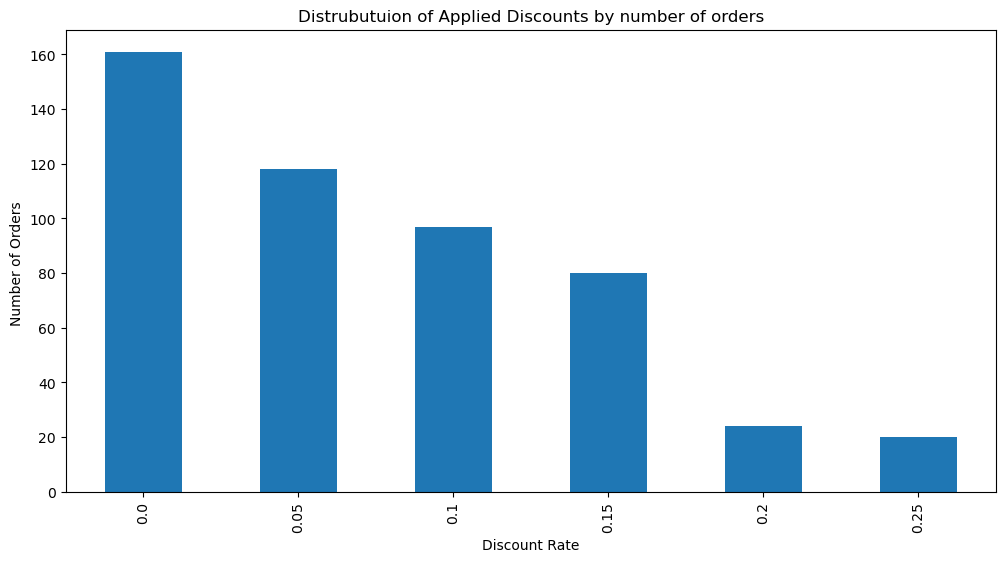

In [237]:
#We need to show this in order to help people under stand this more 
#return_rate_by_month = cap_clean.groupby('month_name')['returned'].mean().sort_values(ascending=False)
#plt.figure(figsize=(10,5))
#return_rate_by_month.plot(kind='bar', color='royalblue')
#plt.title('Return Rate Percentage by month')
#plt.ylabel('Return Rate (%)')
#lt.xticks(rotation=45)
#plt.show()


#sns.histplot
plt.figure(figsize=(12,6))
cap_clean["discount_applied"].value_counts().plot(kind='bar')
plt.title("Distrubutuion of Applied Discounts by number of orders")
plt.xlabel('Discount Rate')
plt.ylabel('Number of Orders ')
plt.savefig(ASSET_PATH_1,dpi=300,bbox_inches="tight")
plt.show()





In [194]:
# This shows teh distrubution of discount amount % off an order it shows a tailing off in teh right side as the discount increases the numbers of orders ioncreases  
#plt.figure(figsize=(10,6))
#sns.histplot(cap_clean,x='discount_applied',)#y='total_revenue',hue='returned',alpha=0.7
#plt.title("Distrubutuion of Applied Discounts by number of orders")
#plt.xlabel('Discount Rate')
#plt.ylabel('Number of Orders ')
#plt.show(close=None, block=None)

In [158]:
#sns.countplot(cap_clean,x='customer_segment',hue='returned')
#plt.xlabel('Customer Segments ')
#plt.ylabel('Count Orders')
#plt.title("Count of Customer by Segment  ")
#plt.show(close=None, block=None)

In [239]:
ASSET_PATH_2 = Path('..') / 'outputs' / 'cap_plot_2.png'
ASSET_PATH_2.parent.mkdir(parents=True, exist_ok=True)



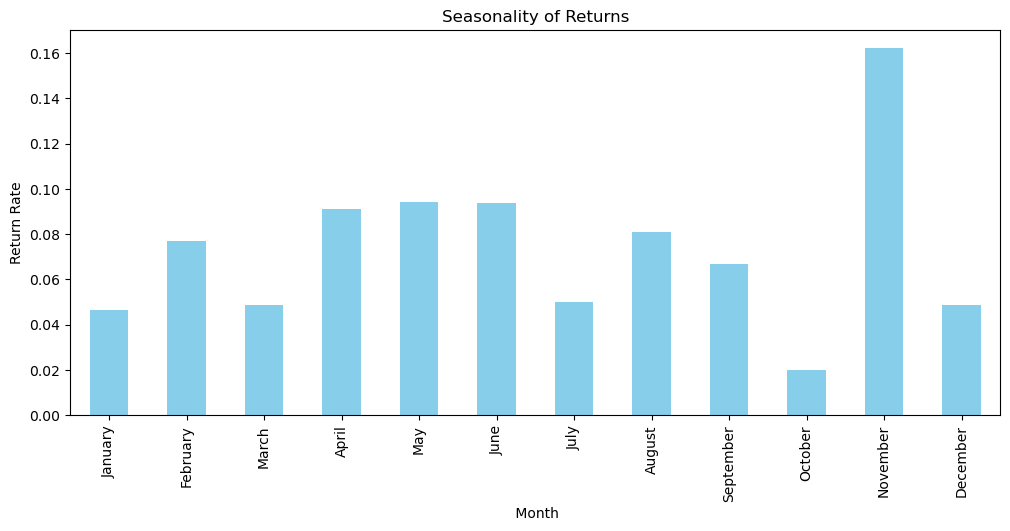

In [241]:
#Need a list of the months to make sure they go in chronological order 
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
cap_clean['month_name'] = pd.Categorical(cap_clean['month_name'], categories=months, ordered=True)

return_by_month = cap_clean.groupby('month_name', observed=False)['returned'].mean()

plt.figure(figsize=(12,5))
return_by_month.plot(kind='bar', color='skyblue')
plt.title("Seasonality of Returns")
plt.ylabel("Return Rate")
plt.xlabel(" Month")
plt.savefig(ASSET_PATH_2,dpi=300,bbox_inches="tight")
plt.show()

In [245]:
ASSET_PATH_3 = Path('..') / 'outputs' / 'cap_plot_3.png'
ASSET_PATH_3.parent.mkdir(parents=True, exist_ok=True)



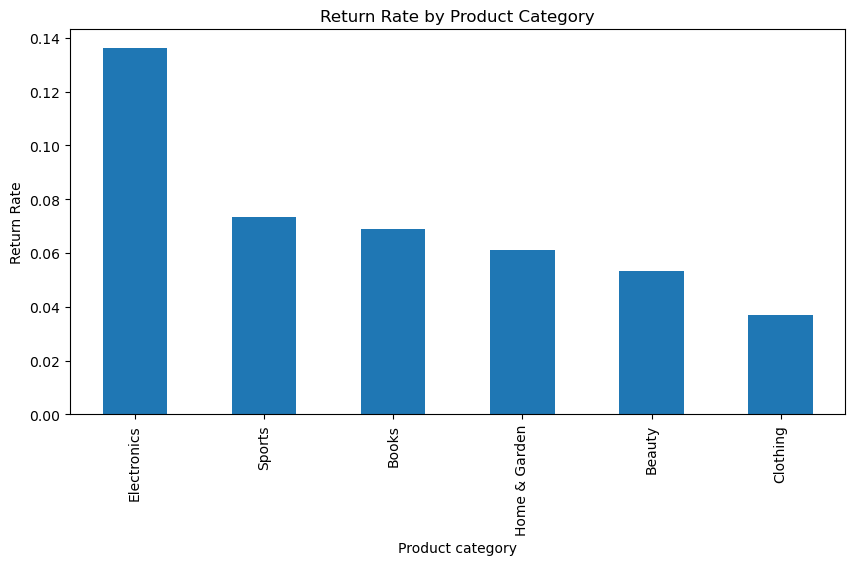

In [247]:
return_by_category = (

    cap_clean.groupby('product_category')['returned'].mean().sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
return_by_category.plot(kind='bar')
plt.title("Return Rate by Product Category")
plt.ylabel("Return Rate")
plt.xlabel("Product category")
plt.savefig(ASSET_PATH_3,dpi=300,bbox_inches="tight")
plt.show()


In [249]:
ASSET_PATH_4 = Path('..') / 'outputs' / 'cap_plot_4.png'
ASSET_PATH_4.parent.mkdir(parents=True, exist_ok=True)

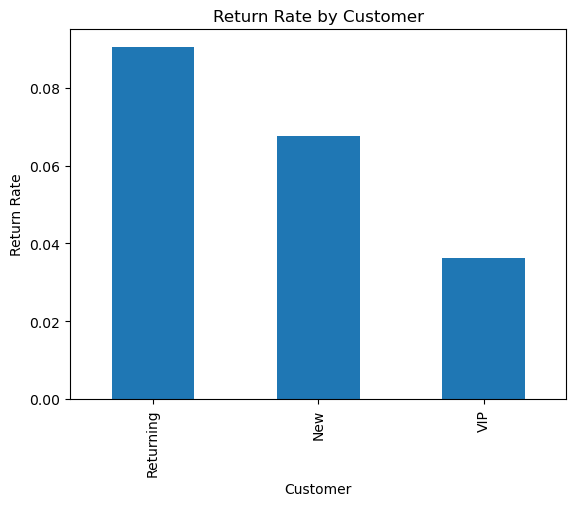

In [251]:
rev_by_segment = (

    cap_clean.groupby('customer_segment')['returned'].mean().sort_values(ascending=False)
)
rev_by_segment.plot(kind='bar')
plt.title("Return Rate by Customer")
plt.ylabel("Return Rate")
plt.xlabel("Customer")
plt.savefig(ASSET_PATH_4,dpi=300,bbox_inches="tight")
plt.show()

### 7.2 Group-Based Analysis

Use `.groupby()` to compare groups.

Examples:
- Average revenue by customer segment
- Return rate by product category
- Average price by neighborhood
- Life expectancy by continent


In [162]:
#plt.figure(figsize=(12,6))
#sns.countplot(cap_clean,x='product_category',hue='returned')
#plt.xlabel('Product Categories')
#plt.ylabel('Count Orders')
#plt.title("Product Category Sales vs Returns  ")
#plt.show(close=None, block=None)

In [52]:
avg_rev_by_category = (

    cap_clean.groupby('product_category')['total_revenue'].mean().sort_values(ascending=False)
)

In [53]:
avg_rev_by_category

product_category
Clothing         820.771111
Electronics      808.420000
Home & Garden    801.477683
Beauty           791.067447
Books            697.599425
Sports           679.072353
Name: total_revenue, dtype: float64

In [54]:
sum_of_orders_by_segment = (

    cap_clean.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)
)

In [55]:
sum_of_orders_by_segment

product_category
Beauty           74360.34
Electronics      71140.96
Clothing         66482.46
Home & Garden    65721.17
Books            60691.15
Sports           46176.92
Name: total_revenue, dtype: float64

In [164]:
return_by_category

product_category
Electronics      0.136364
Sports           0.073529
Books            0.068966
Home & Garden    0.060976
Beauty           0.053191
Clothing         0.037037
Name: returned, dtype: float64

In [57]:
return_by_segment = (

    cap_clean.groupby('customer_segment')['returned'].sum().sort_values(ascending=False)
)
return_by_segment

customer_segment
Returning    19
New          14
VIP           3
Name: returned, dtype: int64

In [58]:
avg_rev_segment =(

    cap_clean.groupby('customer_segment')['total_revenue'].mean().sort_values(ascending=False)
)
avg_rev_segment

customer_segment
New          805.060242
VIP          770.136988
Returning    733.353143
Name: total_revenue, dtype: float64

In [59]:
return_by_region = (
    cap_clean.groupby('region')['returned'].mean().sort_values(ascending=False)
)
return_by_region

region
South      0.104167
East       0.086022
West       0.064815
Central    0.057692
North      0.050505
Name: returned, dtype: float64

In [60]:
rev_by_segment = (

    cap_clean.groupby('customer_segment')['returned'].mean().sort_values(ascending=False)
)
rev_by_segment

customer_segment
Returning    0.090476
New          0.067633
VIP          0.036145
Name: returned, dtype: float64

In [61]:
market_channel_return_rate = (

    cap_clean.groupby('marketing_channel')['returned'].mean().sort_values(ascending=False)

)
market_channel_return_rate

marketing_channel
Direct            0.105263
Email             0.071429
Organic Search    0.066667
Social Media      0.065217
Referral          0.064103
Paid Search       0.049180
Name: returned, dtype: float64

In [62]:
cust_satisfaction_return = (


    cap_clean.groupby('customer_satisfaction')['returned'].mean().sort_values(ascending=False)
)
cust_satisfaction_return

customer_satisfaction
3.0    0.096000
5.0    0.074627
4.0    0.062500
2.0    0.000000
Name: returned, dtype: float64

In [63]:
numeric_cols = cap_clean.select_dtypes(include=['number'])


In [64]:
numeric_cols

,product_price,quantity,discount_applied,total_revenue,customer_satisfaction,returned,estimated_revenue,month_num
0,324.06,1,0.10,295.34,4.0,0,291.6540,1
1,352.42,5,0.00,1758.36,4.0,0,1762.1000,1
2,457.24,2,0.00,925.65,4.0,0,914.4800,1
3,52.72,1,0.10,43.75,4.0,0,47.4480,1
4,299.91,3,0.15,783.52,5.0,0,764.7705,1
...,...,...,...,...,...,...,...,...
495,270.61,5,0.15,1156.41,4.0,0,1150.0925,12
496,405.58,1,0.15,383.44,4.0,0,344.7430,12
497,285.83,2,0.25,436.83,4.0,0,428.7450,12
498,296.67,2,0.00,577.75,4.0,0,593.3400,12


### 7.3 Relationship Analysis

Explore relationships between variables.

Examples:
- Revenue vs discount
- Sale price vs square footage
- Satisfaction vs return status


In [66]:
numerical_columns = [


    'product_price',
    'quantity',
    'discount_applied',
    'total_revenue',
    'customer_satisfaction',
    'returned',
    'estimated_revenue',
    'month_num'
]

In [67]:
numerical_corr = cap_clean[numerical_columns].corr()

numerical_corr

,product_price,quantity,discount_applied,total_revenue,customer_satisfaction,returned,estimated_revenue,month_num
product_price,1.000000,0.094104,0.003102,0.726552,0.013667,0.098437,0.725970,0.023575
quantity,0.094104,1.000000,-0.057867,0.659515,-0.068797,-0.006267,0.660141,-0.012755
discount_applied,0.003102,-0.057867,1.000000,-0.160250,0.233428,0.011783,-0.162634,0.022979
total_revenue,0.726552,0.659515,-0.160250,1.000000,-0.067194,0.066427,0.999423,-0.041100
customer_satisfaction,0.013667,-0.068797,0.233428,-0.067194,1.000000,-0.027551,-0.068549,-0.039356
returned,0.098437,-0.006267,0.011783,0.066427,-0.027551,1.000000,0.061382,0.009607
estimated_revenue,0.725970,0.660141,-0.162634,0.999423,-0.068549,0.061382,1.000000,-0.042155
month_num,0.023575,-0.012755,0.022979,-0.041100,-0.039356,0.009607,-0.042155,1.000000


In [253]:
ASSET_PATH_5 = Path('..') / 'outputs' / 'cap_plot_4.png'
ASSET_PATH_5.parent.mkdir(parents=True, exist_ok=True)

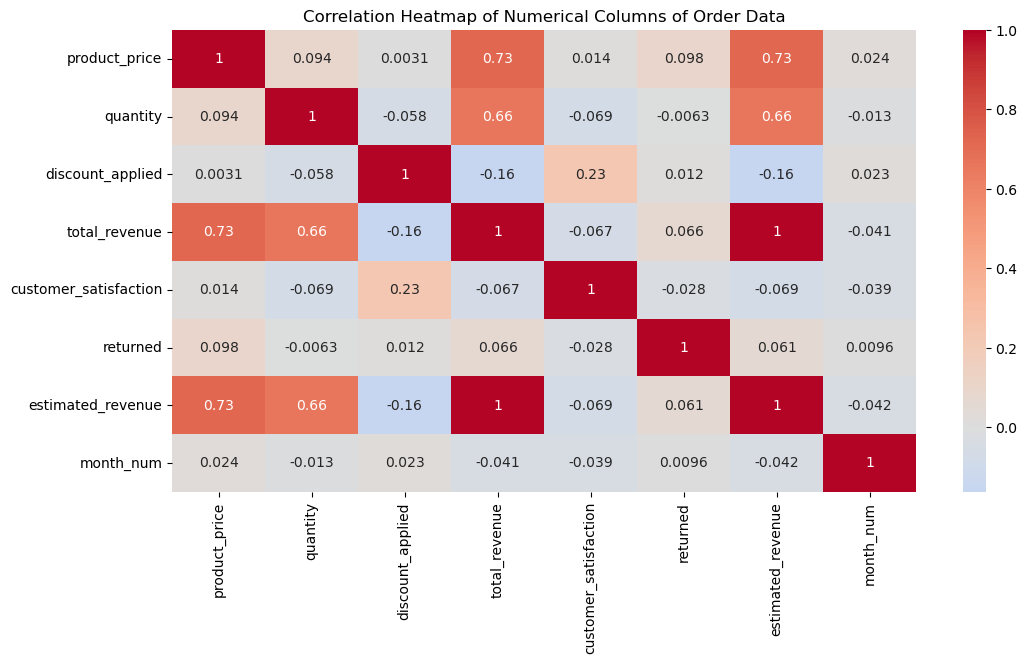

In [255]:
#Creating  Correlation heatmap for all numerical 
plt.figure(figsize=(12,6))
sns.heatmap(numerical_corr,annot=True,cmap='coolwarm',center=0)
plt.title("Correlation Heatmap of Numerical Columns of Order Data")

plt.savefig(ASSET_PATH_5,dpi=300,bbox_inches="tight")
plt.show()

## 8. Insights and Recommendations

Use this section to turn your analysis into conclusions.

Avoid weak observations like:

> VIP customers have higher revenue.

Instead, write stronger insights:

> VIP customers generate higher average revenue and lower return rates, suggesting that retention campaigns focused on VIP customers may produce strong business value.

### Insight 1

> Electronics have the highest rate of return Electronics 0.136 as almost 14 percent in addition to that all other caetgories are much less than
> that  it has almost 2x over teh next category. electronics 

> 
### Recommendation 1

> I would introduce either certain policies for elctronics because they are also show have a consistenly high return rate and making even making them limited retunr windows to make sure we can end this 

### Insight 2

> retuning ciutsomersand new customers account for a majority of returns along with new customers as vip dont account for that much of the returns.

### Recommendation 2

> TI would put into effect a small restocking fee affecting returning customers, because you know they're going to reorder but dish it to the new customers so you cvan acquire them. 


## 9. Optional: Working With Multiple Datasets

Only use this section if your project includes more than one dataset.

Use `pd.merge()` when two datasets share a common key.


In [71]:
# Example merge pattern

# left_df = pd.read_csv(DATA_RAW / "left_dataset.csv")
# right_df = pd.read_csv(DATA_RAW / "right_dataset.csv")

# merged_df = pd.merge(
#     left_df,
#     right_df,
#     on="shared_key_column",
#     how="inner"
# )

# merged_df.head()


## 10. Optional: Simple Modeling

Modeling is optional for this capstone.

Only include a model if it supports your main question.

Keep it simple:
- Linear Regression for numeric prediction
- Logistic Regression for classification

Focus on explaining what you tried and what you learned.


### Modeling Summary

If you included a model, answer:

- What were you trying to predict?
- What features did you use?
- How did the model perform?
- What are the limitations?
- Did the model help answer your main question?

> TODO: Write your modeling summary here.


## 11. Final Project Summary

Use this section to summarize your project.

Your final summary should include:

1. Problem statement
2. Dataset used
3. Main analysis steps
4. Key insights
5. Recommendations
6. Limitations
7. Future work

You should also save a short version of this summary in:

```text
docs/project_summary.md
```


### Final Summary

> TODO: Write your final project summary here.


## 12. Final Notebook Checklist

Before submitting:

- [ ] Notebook runs from top to bottom without errors
- [ ] Problem statement is clear
- [ ] Dataset is loaded from a relative path
- [ ] Cleaning steps are documented
- [ ] At least 2 visualizations are included
- [ ] At least 2 insights are clearly explained
- [ ] Recommendations are tied to evidence
- [ ] Cleaned dataset is saved
- [ ] Project summary is completed
- [ ] Files are organized in the required repo structure
